# TORNADIC CASE PROCESS

The new case parameters are as follows:

Tor: Within 30 minutes of first tornado report

Nontor(Tor) --> Pretor: Before the 30 min before first tornado report

In [1]:
from case_functions import *


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
storm_id = 1
meso_id = 1, 10, 17, 20

In [49]:
d = '20240523'
ka = 'ka1'
Ka = 'Ka1'
weights = [0.05, 0.2, 0.5, 0.2, 0.05]

In [4]:
tobac_features_xr_refl = xr.open_dataset(f'/Users/juliabman/Desktop/research2024/tobac_Save/{d}_tobac_Plot/{d}_Track_refl.nc')
tobac_df_refl = tobac_id(tobac_features_xr_refl, storm_id)
latitude_weighted_tobac, longitude_weighted_tobac, storm_bearing, storm_speed, storm_times = storm_speed_and_bearing(tobac_df_refl, weights)

tobac_features_xr_shear = xr.open_dataset(f'/Users/juliabman/Desktop/research2024/tobac_Save/{d}_tobac_Plot/{d}_Track_shear.nc')
tobac_df_shear = tobac_id(tobac_features_xr_shear, meso_id)
latitude_weighted_tobac_meso, longitude_weighted_tobac_meso, meso_bearing, meso_speed, meso_times = storm_speed_and_bearing(tobac_df_shear, weights)

/Users/juliabman/Desktop/research2024/cases/case_functions.py:306: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  tobac_times_datetime = tobac_times.astype('datetime64[s]')
/Users/juliabman/Desktop/research2024/cases/case_functions.py:306: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Va

In [5]:
#grib_nc = xr.open_dataset(f'/Users/juliabman/Desktop/concat_test/{d}_grib.nc')
#lats, lons, times, shears = azshear_grib_variables(grib_nc)

# data that DOES depend on vads information
vads = sorted(glob.glob(f'/Volumes/Buhrman_4TB/dealiased_data/LIFT24/{d}/{ka}/*.nc'))
print(f'The number of VADs for {d} {Ka} is: {np.shape(vads)} VADs')
gps = pd.read_csv(f'/Volumes/Buhrman_4TB/product_raw/LIFT24/{d}/{ka}/GPS_{Ka}_{d}.txt', dtype='str')

easterlies_vads, westerlies_vads, secondtrip_vads = vads_sort(vads, gps)
print(f"""
The number of easterly VADs for {d} {Ka} is: {np.shape(easterlies_vads)} VADs
The number of westerly VADs for {d} {Ka} is: {np.shape(westerlies_vads)} VADs
The number of second trip VADs for {d} {Ka} is: {np.shape(secondtrip_vads)} VADs
""")

The number of VADs for 20240523 Ka1 is: (602,) VADs

The number of easterly VADs for 20240523 Ka1 is: (374,) VADs
The number of westerly VADs for 20240523 Ka1 is: (77,) VADs
The number of second trip VADs for 20240523 Ka1 is: (151,) VADs



In [6]:
#u, v, h = ground_rel_composite_u_and_v(easterlies_vads, gps)

In [7]:
#hodo_plot(u,v,h, 25, 'Composite Tor Near-field Hodograph',['tab:red', 'tab:green', 'tab:blue', 'tab:purple'])

In [8]:
vad_times, tobac_times, tobac_indeces, tobac_lats, tobac_lons = nearest_tobac_time(easterlies_vads, 
                                                                               np.array(latitude_weighted_tobac),
                                                                               np.array(longitude_weighted_tobac),
                                                                               storm_times[:-1])
storm_bearing_tobac_vads = storm_bearing[tobac_indeces]
storm_vel_tobac_vads = storm_speed[tobac_indeces]

meso_vad_times, meso_times, meso_indeces, meso_lats, meso_lons = nearest_tobac_time(easterlies_vads, 
                                                                               np.array(latitude_weighted_tobac_meso),
                                                                               np.array(longitude_weighted_tobac_meso),
                                                                               meso_times[:-1])

meso_bearing_tobac_vads = meso_bearing[meso_indeces]
meso_vel_tobac_vads = meso_speed[meso_indeces]

vad_df = vad_df_new(easterlies_vads, gps, vad_times, tobac_times, tobac_indeces, tobac_lats, tobac_lons)

Get the max values over time of the target mesocyclones using the Features_shear dataset.

In [9]:
meso_stats = xr.open_dataset(f'/Users/juliabman/Desktop/research2024/tobac_Save/{d}_tobac_Plot/{d}_Features_shear.nc')

In [10]:
meso_stats

<xarray.Dataset>
Dimensions:          (index: 130)
Coordinates:
  * index            (index) int64 0 1 2 3 4 5 6 ... 123 124 125 126 127 128 129
Data variables: (12/14)
    frame            (index) int64 ...
    idx              (index) int64 ...
    hdim_1           (index) int64 ...
    hdim_2           (index) int64 ...
    num              (index) int64 ...
    threshold_value  (index) int64 ...
    ...               ...
    max              (index) float32 ...
    feature          (index) int64 ...
    time             (index) datetime64[ns] ...
    timestr          (index) <U19 ...
    latitude         (index) float64 ...
    longitude        (index) float64 ...

In [11]:
if not isinstance(meso_id, (list, set)):
    meso_id = [meso_id]
    
    meso_indeces = tobac_features_xr_shear['cell'].where(tobac_features_xr_shear['cell'].isin(meso_id), drop=True)

meso_ids = meso_indeces.index


In [12]:
meso_ids

<xarray.DataArray 'index' (index: 42)>
array([  0,   1,   2,   3,   4,   5,   6,   8,  10,  11,  14,  17,  18,  19,
        20,  21,  23,  24,  25,  26,  27,  29,  34,  54,  57,  59,  64,  72,
        74,  76,  77,  80,  82,  85,  89,  93,  97, 102, 104, 107, 112, 113])
Coordinates:
  * index    (index) int64 0 1 2 3 4 5 6 8 10 ... 89 93 97 102 104 107 112 113

In [13]:
if not isinstance(meso_ids, (list, set)):
    meso_ids = [meso_ids]
    
    meso_indeces2 = meso_stats['idx'].index.where(meso_stats['idx'].index.isin(meso_ids), drop=True)

meso_ids_stats = meso_indeces2.index


In [14]:
meso_ids_stats

<xarray.DataArray 'index' (index: 42)>
array([  0,   1,   2,   3,   4,   5,   6,   8,  10,  11,  14,  17,  18,  19,
        20,  21,  23,  24,  25,  26,  27,  29,  34,  54,  57,  59,  64,  72,
        74,  76,  77,  80,  82,  85,  89,  93,  97, 102, 104, 107, 112, 113])
Coordinates:
  * index    (index) int64 0 1 2 3 4 5 6 8 10 ... 89 93 97 102 104 107 112 113

In [15]:
wanted_meso_max = meso_stats['max'][meso_ids_stats].values

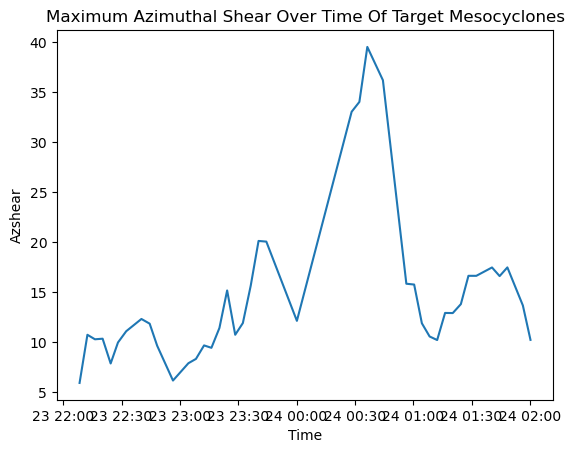

In [16]:
fig = plt.figure()
plt.plot(meso_stats['time'][meso_ids_stats], wanted_meso_max)
plt.title('Maximum Azimuthal Shear Over Time Of Target Mesocyclones')
plt.xlabel('Time')
plt.ylabel('Azshear')
plt.show()

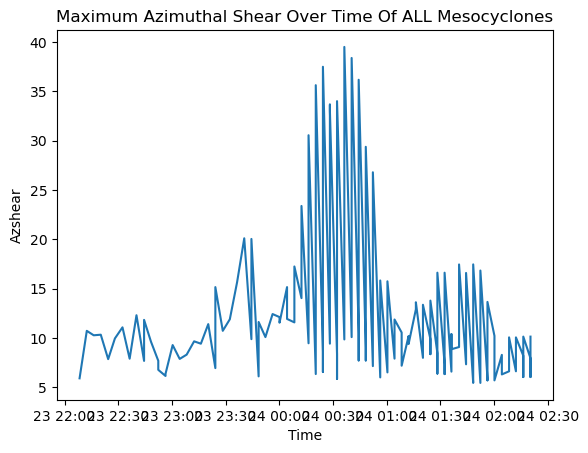

In [17]:
fig = plt.figure()
plt.plot(meso_stats['time'], meso_stats['max'].values)
plt.title('Maximum Azimuthal Shear Over Time Of ALL Mesocyclones')
plt.xlabel('Time')
plt.ylabel('Azshear')
plt.show()

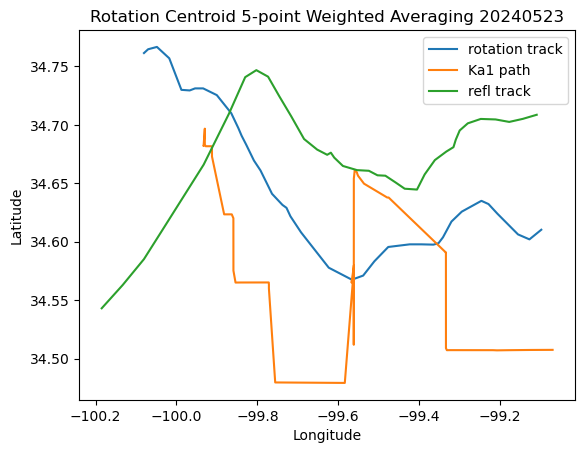

In [18]:
from matplotlib import rcParams, rcParamsDefault
rcParams.update(rcParamsDefault)

fig = plt.figure()
plt.plot(longitude_weighted_tobac_meso, latitude_weighted_tobac_meso)
plt.plot(vad_df.Lonmean, vad_df.Latmean)
#plt.plot(vad_df_ka2.Lonmean, vad_df_ka2.Latmean)
plt.plot(longitude_weighted_tobac, latitude_weighted_tobac)
plt.title(f'Rotation Centroid 5-point Weighted Averaging {d}')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(['rotation track', f'{Ka} path', 'refl track'])
plt.show()

In [19]:
meso_to_ka_dist= []
meso_to_ka_bear = []
for i in range(len(meso_lats)):
    #print(rot_lats[i])
    fwd_az, back_az, distance = geodesic.inv(vad_df.Lonmean[i], vad_df.Latmean[i], meso_lons[i], meso_lats[i])
    # distance in m, az in degrees clockwise from N
    distance_km = distance / 1000
    meso_to_ka_dist.append(distance_km)
    meso_to_ka_bear.append(fwd_az)
    #storm_bearing_rot.append(fwd_az)

(374,)
(374,)


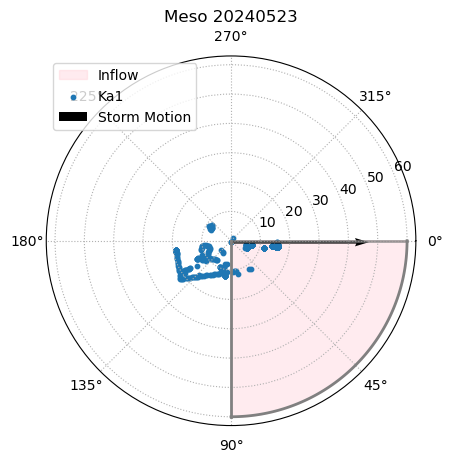

In [20]:
theta, r = polar_plot(f'Meso {d}', meso_to_ka_bear, storm_bearing_tobac_vads, meso_to_ka_dist, f'{Ka}')

In [52]:
#theta2, r2 = polar_plot(f'Meso {d}', meso_to_ka_bear, np.zeros_like(meso_to_ka_bear), meso_to_ka_dist, f'{Ka}')

In [22]:
theta_deg = theta * (180/np.pi)

In [23]:
np.shape(theta_deg[theta_deg < 90])

(201,)

In [50]:
data = pd.read_csv(f'/Users/juliabman/Desktop/storm_events_data/storm_data_search_results_{d}.csv')

In [26]:
#data = pd.read_csv(f'/Users/juliabman/Desktop/storm_events_data/storm_data_search_results_{d}.csv')
#time_from_tor = time_from_tor(vad_df, data, str('Tornado'), str('PLAINS YOAKUM CO ARP'), str('US/Central'), False)
#time_from_tor = time_from_tor(vad_df, data, str('Tornado'), str('SILVERTON'), str('US/Central'), False)
#time_from_tor = time_from_tor(vad_df, data, str('Tornado'), str('BROADVIEW'), str('US/Mountain'), False)
#time_from_tor = time_from_tor(vad_df, data, str('Tornado'), str('CUSTER CITY'), str('US/Central'), False)
#time_from_tor = time_from_tor(vad_df, data, str('Tornado'), str('HAWLEY'), str('US/Central'), False)
time_from_tor = time_from_tor(vad_df, data, str('Tornado'), str('DUKE'), str('US/Central'), False)
vad_df['Time From Tor'] = time_from_tor

1804 DUKE
1825 DUKE
2024-05-23 18:04:00
2024-05-23 18:25:00
min:2024-05-24 00:04:00+00:00


In [27]:
vad_df

,Datetime,Radar,Velmean,Velvar,Bearmean,Latmean,Latvar,Lonmean,Lonvar,tobac_times,tobac_indeces,tobac_lats,tobac_lons,Time From Tor
0,2024-05-23 20:25:42,<pyart.core.radar.Radar object at 0x328d17760>,0.000000,0.000000,17.450000,34.682307,5.437072e-29,-99.932830,2.174829e-28,2024-05-23 22:14:17,0,34.542994,-100.184758,-218.300000
1,2024-05-23 20:25:55,<pyart.core.radar.Radar object at 0x329dbf850>,0.000000,0.000000,17.450000,34.682307,5.469436e-29,-99.932831,7.478633e-13,2024-05-23 22:14:17,0,34.542994,-100.184758,-218.083333
2,2024-05-23 20:26:08,<pyart.core.radar.Radar object at 0x3298bf730>,0.000000,0.000000,17.450000,34.682307,5.469436e-29,-99.932832,0.000000e+00,2024-05-23 22:14:17,0,34.542994,-100.184758,-217.866667
3,2024-05-23 20:26:21,<pyart.core.radar.Radar object at 0x32a476cd0>,0.000000,0.000000,17.450000,34.682307,5.469436e-29,-99.932832,0.000000e+00,2024-05-23 22:14:17,0,34.542994,-100.184758,-217.650000
4,2024-05-23 20:26:34,<pyart.core.radar.Radar object at 0x329d97bb0>,0.000000,0.000000,17.450000,34.682308,6.410256e-13,-99.932832,0.000000e+00,2024-05-23 22:14:17,0,34.542994,-100.184758,-217.433333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,2024-05-24 02:07:19,<pyart.core.radar.Radar object at 0x53a1d6a90>,27.443077,11.192623,89.966154,34.507311,2.955840e-12,-99.131557,3.531775e-07,2024-05-24 01:51:01,35,34.705170,-99.143773,123.316667
370,2024-05-24 02:07:33,<pyart.core.radar.Radar object at 0x32a4f8070>,41.619231,9.818074,89.641538,34.507323,3.076923e-11,-99.128829,8.387285e-07,2024-05-24 01:51:01,35,34.705170,-99.143773,123.550000
371,2024-05-24 02:07:46,<pyart.core.radar.Radar object at 0x538117520>,50.046154,1.580409,89.861538,34.507333,1.851852e-12,-99.125442,1.213201e-06,2024-05-24 01:51:01,35,34.705170,-99.143773,123.766667
372,2024-05-24 02:10:24,<pyart.core.radar.Radar object at 0x53a2fcd90>,65.363077,0.265790,89.890000,34.507422,1.566952e-12,-99.075345,2.040027e-06,2024-05-24 01:51:01,35,34.705170,-99.143773,126.400000


In [28]:
all_u, all_v =  u_and_v(easterlies_vads, gps, storm_vel_tobac_vads, storm_bearing_tobac_vads)

In [29]:
all_u_df = pd.DataFrame(all_u)
all_u_df['u or v'] = 'u'
all_u_df['Distance'] = r
all_u_df['Angle'] = theta_deg
all_u_df['Time From Tor (min)'] = vad_df['Time From Tor']
all_u_df['Datetime'] = vad_df['Datetime']

all_v_df = pd.DataFrame(all_v)
all_v_df['u or v'] = 'v'
all_v_df['Distance'] = r
all_v_df['Angle'] = theta_deg
all_v_df['Time From Tor (min)'] = vad_df['Time From Tor']
all_v_df['Datetime'] = vad_df['Datetime']
all_uv = pd.concat([all_u_df, all_v_df], axis=0)

In [30]:
all_uv

,0,1,2,3,4,5,6,7,8,9,...,191,192,193,194,195,u or v,Distance,Angle,Time From Tor (min),Datetime
0,-11.943426,-12.084568,-12.309349,-12.474182,-12.474182,-12.728498,-12.755848,-12.844185,-12.939651,-12.865853,...,-2.206125,-3.189539,-3.931596,-5.712186,-6.645830,u,16.109556,8.090568,-218.300000,2024-05-23 20:25:42
1,-11.883518,-11.996599,-12.167171,-12.332963,-12.332963,-12.537083,-12.534195,-12.574114,-12.644382,-12.560809,...,-0.868636,-1.301112,-1.655109,-3.596654,-4.125637,u,16.109497,8.090704,-218.083333,2024-05-23 20:25:55
2,-10.923961,-10.958689,-11.081999,-11.225552,-11.225552,-11.368284,-11.441235,-11.596684,-11.710390,-11.812451,...,-4.867886,-5.176274,-5.882717,-6.574956,-7.028929,u,16.109428,8.090863,-217.866667,2024-05-23 20:26:08
3,-10.507832,-10.479363,-10.536413,-10.716601,-10.716601,-10.967036,-11.121256,-11.408457,-11.605662,-11.906357,...,-5.123293,-6.142747,-6.505371,-7.267149,-7.989053,u,16.109428,8.090863,-217.650000,2024-05-23 20:26:21
4,-10.135777,-10.214960,-10.364912,-10.545396,-10.545396,-10.895993,-11.064620,-11.359598,-11.556850,-11.829837,...,-2.001201,-2.681230,-3.333614,-4.445424,-5.110915,u,16.109358,8.090482,-217.433333,2024-05-23 20:26:34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,-3.212336,-3.150904,-3.152608,-3.270832,-3.270832,-3.528530,-3.814383,-4.242861,-4.485825,-5.052770,...,17.270422,17.282471,17.288441,17.299145,17.306650,v,10.510658,84.028308,123.316667,2024-05-24 02:07:19
370,-4.572890,-4.430432,-4.289411,-4.173113,-4.173113,-3.945287,-3.856972,-3.648713,-3.549352,-3.408082,...,16.893749,16.907543,16.922287,16.942768,16.963360,v,10.503407,82.664498,123.550000,2024-05-24 02:07:33
371,-8.361743,-8.701324,-8.949174,-9.105219,-9.105219,-9.430155,-9.429153,-9.490714,-9.512763,-9.250147,...,16.826740,16.827358,16.837400,16.849909,16.851837,v,10.503306,80.969434,123.766667,2024-05-24 02:07:46
372,-7.203273,-7.177958,-7.036808,-6.862898,-6.862898,-6.659389,-6.464805,-6.048552,-5.832798,-5.426066,...,16.786188,16.797600,16.821186,16.835989,16.854568,v,11.532170,57.489880,126.400000,2024-05-24 02:10:24


In [31]:
all_uv.to_csv(f'case_dfs/new/{d}_uv_{ka}_all.csv', index=False)

# VAD categorization

In [32]:
inflow_vads, not_inflow_vads, nearfield_vads, farfield_vads, inflow_column, distance_column = inflow_near_far_test(storm_bearing_tobac_vads, theta_deg, easterlies_vads, meso_to_ka_dist, 90, 0)

16.109555742769675
0
16.10949668401326
1
16.10942778224917
2
16.10942778224917
2
16.10935789775162
4
16.10932683820404
5
16.10932683820404
5
16.10932683820404
5
16.10932683820404
5
16.10932683820404
5
16.10932683820404
5
16.10932683820404
5
16.10932683820404
5
16.109365662660615
13
16.10942778224917
2
16.10942778224917
2
16.10942778224917
2
16.10939825296118
17
16.109299822162576
18
16.109299822162576
18
16.109268762053077
20
16.109198877318438
21
16.109070916860553
22
16.109070916860553
22
16.109070916860553
22
16.109070916860553
22
16.10889899245111
26
16.108842011879204
27
16.108842011879204
27
16.108842011879204
27
16.108842011879204
27
16.108842011879204
27
16.108842011879204
27
16.108842011879204
27
16.108842011879204
27
16.108842011879204
27
16.108842011879204
27
16.108842011879204
27
16.108842011879204
27
16.108842011879204
27
16.10554628503262
40
16.10554628503262
40
16.105490461018924
42
16.105573398623864
43
16.105573398623864
43
16.105573398623864
43
16.105573398623864
43
1

In [33]:
original_list = nearfield_vads
nearfield_vads = list(dict.fromkeys(original_list))
np.shape(nearfield_vads)

(102,)

In [34]:
og = farfield_vads
farfield_vads = list(dict.fromkeys(og))
np.shape(farfield_vads)

(0,)

In [35]:
vad_df['Inflow'] = inflow_column
vad_df['Distance'] = distance_column
vad_df['Angle'] = theta_deg

In [36]:
#data = pd.read_csv(f'/Users/juliabman/Desktop/storm_events_data/storm_data_search_results_{d}.csv')
#tor_df, tor_nontor = tor_id_new(vad_df, data, str('Tornado'), str('PLAINS YOAKUM CO ARP'), str('US/Central'), False)
#tor_df, tor_nontor = tor_id_new(vad_df, data, str('Tornado'), str('SILVERTON'), str('US/Central'), False)
#tor_df, tor_nontor = tor_id_new(vad_df, data, str('Tornado'), str('CUSTER CITY'), str('US/Central'), False)
#tor_df, tor_nontor = tor_id_new(vad_df, data, str('Tornado'), str('HAWLEY'), str('US/Central'), False)
tor_df, tor_nontor = tor_id_new(vad_df, data, str('Tornado'), str('DUKE'), str('US/Central'), False)
vad_df['Tor Times'] = tor_df
vad_df['Tor or Nontor'] = tor_nontor

1804 DUKE
1825 DUKE
2024-05-23 18:04:00
2024-05-23 18:25:00
2024-05-24 00:04:00+00:00
2024-05-24 00:57:00+00:00


In [37]:
vad_df['Tor or Nontor'].value_counts()

Tor or Nontor
pre tor     186
post tor     95
tor          93
Name: count, dtype: int64

In [38]:
vad_df.Inflow.value_counts()

Inflow
Nearfield        201
Not in Inflow    173
Name: count, dtype: int64

In [39]:
vad_df

,Datetime,Radar,Velmean,Velvar,Bearmean,Latmean,Latvar,Lonmean,Lonvar,tobac_times,tobac_indeces,tobac_lats,tobac_lons,Time From Tor,Inflow,Distance,Angle,Tor Times,Tor or Nontor
0,2024-05-23 20:25:42,<pyart.core.radar.Radar object at 0x328d17760>,0.000000,0.000000,17.450000,34.682307,5.437072e-29,-99.932830,2.174829e-28,2024-05-23 22:14:17,0,34.542994,-100.184758,-218.300000,Nearfield,16.109556,8.090568,pre tor,pre tor
1,2024-05-23 20:25:55,<pyart.core.radar.Radar object at 0x329dbf850>,0.000000,0.000000,17.450000,34.682307,5.469436e-29,-99.932831,7.478633e-13,2024-05-23 22:14:17,0,34.542994,-100.184758,-218.083333,Nearfield,16.109497,8.090704,pre tor,pre tor
2,2024-05-23 20:26:08,<pyart.core.radar.Radar object at 0x3298bf730>,0.000000,0.000000,17.450000,34.682307,5.469436e-29,-99.932832,0.000000e+00,2024-05-23 22:14:17,0,34.542994,-100.184758,-217.866667,Nearfield,16.109428,8.090863,pre tor,pre tor
3,2024-05-23 20:26:21,<pyart.core.radar.Radar object at 0x32a476cd0>,0.000000,0.000000,17.450000,34.682307,5.469436e-29,-99.932832,0.000000e+00,2024-05-23 22:14:17,0,34.542994,-100.184758,-217.650000,Nearfield,16.109428,8.090863,pre tor,pre tor
4,2024-05-23 20:26:34,<pyart.core.radar.Radar object at 0x329d97bb0>,0.000000,0.000000,17.450000,34.682308,6.410256e-13,-99.932832,0.000000e+00,2024-05-23 22:14:17,0,34.542994,-100.184758,-217.433333,Nearfield,16.109358,8.090482,pre tor,pre tor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,2024-05-24 02:07:19,<pyart.core.radar.Radar object at 0x53a1d6a90>,27.443077,11.192623,89.966154,34.507311,2.955840e-12,-99.131557,3.531775e-07,2024-05-24 01:51:01,35,34.705170,-99.143773,123.316667,Nearfield,10.510658,84.028308,post tor,post tor
370,2024-05-24 02:07:33,<pyart.core.radar.Radar object at 0x32a4f8070>,41.619231,9.818074,89.641538,34.507323,3.076923e-11,-99.128829,8.387285e-07,2024-05-24 01:51:01,35,34.705170,-99.143773,123.550000,Nearfield,10.503407,82.664498,post tor,post tor
371,2024-05-24 02:07:46,<pyart.core.radar.Radar object at 0x538117520>,50.046154,1.580409,89.861538,34.507333,1.851852e-12,-99.125442,1.213201e-06,2024-05-24 01:51:01,35,34.705170,-99.143773,123.766667,Nearfield,10.503306,80.969434,post tor,post tor
372,2024-05-24 02:10:24,<pyart.core.radar.Radar object at 0x53a2fcd90>,65.363077,0.265790,89.890000,34.507422,1.566952e-12,-99.075345,2.040027e-06,2024-05-24 01:51:01,35,34.705170,-99.143773,126.400000,Nearfield,11.532170,57.489880,post tor,post tor


In [40]:
vad_df.to_csv(f'case_dfs/new/{d}_{ka}_vad_df.csv', index=False)

In [ ]:
# tor_nf_vads_loc = vad_df[vad_df['Tor or Nontor'] == 'tor'][vad_df['Inflow'] == 'Nearfield']
# id = tor_nf_vads_loc.index.values
# tor_nearfield_vads = [easterlies_vads[i] for i in id]

# nontor_nf_vads_loc = vad_df[vad_df['Tor or Nontor'] == 'pre tor'][vad_df['Inflow'] == 'Nearfield']
# id = nontor_nf_vads_loc.index.values
# nontor_nearfield_vads = [easterlies_vads[i] for i in id]

# tor_ff_vads_loc = vad_df[vad_df['Tor or Nontor'] == 'tor'][vad_df['Inflow'] == 'Farfield']
# id = tor_ff_vads_loc.index.values
# tor_farfield_vads = [easterlies_vads[i] for i in id]

# nontor_ff_vads_loc = vad_df[vad_df['Tor or Nontor'] == 'pre tor'][vad_df['Inflow'] == 'Farfield']
# id = nontor_ff_vads_loc.index.values
# nontor_farfield_vads = [easterlies_vads[i] for i in id]

In [ ]:
#tor_nf_vads_loc = vad_df[vad_df['Time From Tor'] >= -60][vad_df['Time From Tor'] <=0][vad_df['Distance'] <= 20][vad_df['Angle'] <= 90]
tor_nf_vads_loc = vad_df[vad_df['Time From Tor'] == 0][vad_df['Distance'] <= 20][vad_df['Angle'] <= 90]
id = tor_nf_vads_loc.index.values
tor_nearfield_vads = [easterlies_vads[i] for i in id]

#pretor_nf_vads_loc = vad_df[vad_df['Time From Tor'] < -60][vad_df['Distance'] <= 20]
pretor_nf_vads_loc = vad_df[vad_df['Time From Tor'] < 0][vad_df['Distance'] <= 20][vad_df['Angle'] <= 90]
id = pretor_nf_vads_loc.index.values
pretor_nearfield_vads = [easterlies_vads[i] for i in id]

#tor_ff_vads_loc = vad_df[vad_df['Time From Tor'] >= -60][vad_df['Time From Tor'] <=0][vad_df['Distance'] > 20][vad_df['Angle'] <= 90]
tor_ff_vads_loc = vad_df[vad_df['Time From Tor'] == 0][vad_df['Distance'] > 20][vad_df['Angle'] <= 90]
id = tor_ff_vads_loc.index.values
tor_farfield_vads = [easterlies_vads[i] for i in id]

#pretor_ff_vads_loc = vad_df[vad_df['Time From Tor'] < -60][vad_df['Distance'] > 20]
pretor_ff_vads_loc = vad_df[vad_df['Time From Tor'] < 0][vad_df['Distance'] > 20][vad_df['Angle'] <= 90]
id = pretor_ff_vads_loc.index.values
pretor_farfield_vads = [easterlies_vads[i] for i in id]

posttor_nf_vads_loc = vad_df[vad_df['Time From Tor'] > 0][vad_df['Distance'] <= 20][vad_df['Angle'] <= 90]
id = posttor_nf_vads_loc.index.values
posttor_nearfield_vads = [easterlies_vads[i] for i in id]

posttor_ff_vads_loc = vad_df[vad_df['Time From Tor'] > 0][vad_df['Distance'] > 20][vad_df['Angle'] <= 90]
id = posttor_ff_vads_loc.index.values
posttor_farfield_vads = [easterlies_vads[i] for i in id]

In [ ]:
tor_nearfield_vads = list(dict.fromkeys(tor_nearfield_vads))

pretor_nearfield_vads = list(dict.fromkeys(pretor_nearfield_vads))

tor_farfield_vads = list(dict.fromkeys(tor_farfield_vads))

pretor_farfield_vads = list(dict.fromkeys(pretor_farfield_vads))
np.shape(pretor_farfield_vads)

In [ ]:
np.shape(tor_nearfield_vads)

In [ ]:
np.shape(pretor_nearfield_vads)

In [ ]:
np.shape(tor_farfield_vads)

In [ ]:
tor_nearfield_vad_times, tor_nearfield_times, tor_nearfield_indeces, tor_nearfield_lats, tor_nearfield_lons = nearest_tobac_time(tor_nearfield_vads, 
                                                                                       np.array(latitude_weighted_tobac),
                                                                                       np.array(longitude_weighted_tobac),
                                                                                       storm_times[:-1])
tor_nearfield_bearing = storm_bearing[tor_nearfield_indeces]
tor_nearfield_velocity = storm_speed[tor_nearfield_indeces]

In [ ]:
tor_farfield_vad_times, tor_farfield_times, tor_farfield_indeces, tor_farfield_lats, tor_farfield_lons = nearest_tobac_time(tor_farfield_vads, 
                                                                                       np.array(latitude_weighted_tobac),
                                                                                       np.array(longitude_weighted_tobac),
                                                                                       storm_times[:-1])
tor_farfield_bearing = storm_bearing[tor_farfield_indeces]
tor_farfield_velocity = storm_speed[tor_farfield_indeces]

In [ ]:
pretor_nearfield_vad_times, pretor_nearfield_times, pretor_nearfield_indeces, pretor_nearfield_lats, pretor_nearfield_lons = nearest_tobac_time(pretor_nearfield_vads, 
                                                                                       np.array(latitude_weighted_tobac),
                                                                                       np.array(longitude_weighted_tobac),
                                                                                       storm_times[:-1])
pretor_nearfield_bearing = storm_bearing[pretor_nearfield_indeces]
pretor_nearfield_velocity = storm_speed[pretor_nearfield_indeces]

In [ ]:
pretor_farfield_vad_times, pretor_farfield_times, pretor_farfield_indeces, pretor_farfield_lats, pretor_farfield_lons = nearest_tobac_time(pretor_farfield_vads, 
                                                                                       np.array(latitude_weighted_tobac),
                                                                                       np.array(longitude_weighted_tobac),
                                                                                       storm_times[:-1])
pretor_farfield_bearing = storm_bearing[pretor_farfield_indeces]
pretor_farfield_velocity = storm_speed[pretor_farfield_indeces]

In [ ]:
tor_nearfield_u, tor_nearfield_v, tor_nearfield_heights = composite_u_and_v(tor_nearfield_vads, gps, tor_nearfield_velocity, tor_nearfield_bearing)

In [ ]:
pretor_nearfield_u, pretor_nearfield_v, pretor_nearfield_heights = composite_u_and_v(pretor_nearfield_vads, gps, pretor_nearfield_velocity, pretor_nearfield_bearing)

In [ ]:
tor_farfield_u, tor_farfield_v, tor_farfield_heights = composite_u_and_v(tor_farfield_vads, gps, tor_farfield_velocity, tor_farfield_bearing)

In [ ]:
pretor_farfield_u, pretor_farfield_v, pretor_farfield_heights = composite_u_and_v(pretor_farfield_vads, gps, pretor_farfield_velocity, pretor_farfield_bearing)

In [ ]:
hodo_plot(tor_nearfield_u, tor_nearfield_v, tor_nearfield_heights, 25, 'Composite Tor Near-field Hodograph',['tab:red', 'tab:green', 'tab:blue', 'tab:purple'])

In [ ]:
hodo_plot(pretor_nearfield_u, pretor_nearfield_v, pretor_nearfield_heights, 25, 'Composite Pretor Near-field Hodograph',['tab:red', 'tab:green', 'tab:blue', 'tab:purple'])

In [ ]:
hodo_plot(tor_farfield_u, tor_farfield_v, tor_farfield_heights, 25, 'Composite Tor Far-field Hodograph',['tab:red', 'tab:green', 'tab:blue', 'tab:purple'])

In [ ]:
hodo_plot(pretor_farfield_u, pretor_farfield_v, pretor_farfield_heights, 25, 'Composite Pretor Far-field Hodograph',['tab:red', 'tab:green', 'tab:blue', 'tab:purple'])

In [ ]:
# Add a label to each variable
def add_label(data, label):
    return pd.DataFrame(data).assign(Variable=label)

In [ ]:
#columns = ['NFToru', 'NFTorv', 'FFToru', 'FFTorv', 'NFPreToru', 'NFPreTorv', 'FFPreToru', 'FFPreTorv']
columns = ['NFToru', 'NFTorv', 'NFPreToru', 'NFPreTorv', 'FFPreToru', 'FFPreTorv']
comp_data_uv = [tor_nearfield_u, tor_nearfield_v, nontor_nearfield_u, nontor_nearfield_v,
                nontor_farfield_u, nontor_farfield_v]

comp_field_uv_df = pd.DataFrame(comp_data_uv)
comp_field_uv_df['Variable'] = columns 

In [ ]:
comp_field_uv_df

In [ ]:
comp_field_uv_df.to_csv(f'case_dfs/new/{d}_uv_{ka}.csv', index=False)

In [ ]:
all_tor_nf_u, all_tor_nf_v =  u_and_v(tor_nearfield_vads, gps, tor_nearfield_velocity, tor_nearfield_bearing)

In [ ]:
all_nontor_nf_u, all_nontor_nf_v = u_and_v(nontor_nearfield_vads, gps, nontor_nearfield_velocity, nontor_nearfield_bearing)

In [ ]:
all_tor_ff_u, all_tor_ff_v = u_and_v(tor_farfield_vads, gps, tor_farfield_velocity, tor_farfield_bearing)

In [ ]:
all_nontor_ff_u, all_nontor_ff_v = u_and_v(nontor_farfield_vads, gps, nontor_farfield_velocity, nontor_farfield_bearing)

In [ ]:
columns = ['NFToru', 'NFTorv', 'NFPreToru', 'NFPreTorv', 'FFToru', 'FFTorv', 'FFPreToru', 'FFPreTorv']
data_uv = [all_tor_nf_u, all_tor_nf_v, all_nontor_nf_u, all_nontor_nf_v , all_tor_ff_u, 
                    all_tor_ff_v, all_nontor_ff_u, all_nontor_ff_v]

dfs = []
for v, name in zip(data_uv, columns):
    df = add_label(v, name)
    dfs.append(df)

In [ ]:
df_uv = pd.concat([dfs[0], dfs[1], dfs[2], dfs[3], dfs[4], dfs[5], dfs[6], dfs[7]], ignore_index=True)

In [ ]:
df_uv

In [ ]:
field_uv_all_df = pd.DataFrame(df_uv)
field_uv_all_df.to_csv(f'case_dfs/new/{d}_uv_{ka}_all_prelabeled.csv', index=False)

In [ ]:
for i in pretor_nearfield_vads[20:30]: 
    fig = plt.figure(figsize=(20,10))
    read = pyart.io.read(i)
    print(i[-15:-3])
    time = i[-15:-3]
    #print(f'vehicle speed was {ka2_df.Velmean[i]}')
    radar = read.extract_sweeps([0])
    radar, _, _, _, _, _, _, _, _ = vehicle_correction_vad(radar, gps)
    nyq = radar.instrument_parameters['nyquist_velocity']['data'][0]
    print(f'nyquist velocity: {nyq}')
    display = pyart.graph.RadarMapDisplay(radar)
    ax1 = fig.add_subplot(2,4,1, projection = display.grid_projection)
    display.plot_ppi_map('reflectivity', ax = ax1, vmin = -30, vmax = 30)
    ax1.set_title('Reflectivity')
    #display.plot_ppi_map('corrected_velocity', ax = ax1, 
                         #vmin = -40, vmax = 40, cmap = 'pyart_balance')
    #ax1.set_title('Corrected Velocity')
    ax2 = fig.add_subplot(2,4,2, projection = display.grid_projection)
    display.plot_ppi_map('vad_corrected_velocity', ax = ax2, 
                         vmin = -40, vmax = 40, cmap = 'pyart_balance')
    display.plot_range_ring(2)
    ax2.set_title('Vehicle Corrected Velocity')
    ax3 = fig.add_subplot(2,4,3, projection = display.grid_projection)
    #display.plot_ppi_map('spectrum_width', ax = ax3, cmap = 'cubehelix_r', vmin = 0, vmax = 10)
    #ax3.set_title('Spectrum Width')
    display.plot_ppi_map('vad_corrected_velocity', ax = ax3, vmin = -40, vmax = 40, cmap = 'pyart_balance')
    ax3.set_title('Vehicle Corrected Velocity')
    ax4 = fig.add_subplot(2,4,4, projection = display.grid_projection)
    ax4.set_xlabel('U-component Wind [knots]')
    ax4.set_ylabel('V-component Wind [knots]')
    ax4.set_title('Vehicle motion corrected VAD')
    VAD = pyart.retrieve.vad_browning(radar, 'vad_corrected_velocity', z_want=np.arange(50,2001,10),gatefilter=None)
    vadu = VAD.u_wind*1.94384 # meters to knots
    vadv = VAD.v_wind*1.94384
    hodo = metpy.plots.Hodograph(ax4, component_range=60.)
    hodo.add_grid(increment=5)
    hodo.plot(vadu, vadv)
    plt.suptitle(f'{Ka} Refl, Vr, Spectrum Width at {time}')
    plt.show()

In [ ]:
pretor_nf_dist = vad_df[vad_df['Tor or Nontor'] == 'pre tor']['Distance']
pretor_nf_angle = vad_df[vad_df['Tor or Nontor'] == 'pre tor']['Angle']

In [ ]:
pretheta, prer = polar_plot(f'Meso {d}', pretor_nf_angle, 0, pretor_nf_dist, f'{Ka}')

In [ ]:
t = vad_df[vad_df['Time From Tor'] < 0][vad_df['Distance'] <= 20][vad_df['Angle'] <= 90]

In [ ]:
counts, bins = np.histogram([t['Time From Tor'].values])
plt.hist(bins[:-1], bins, weights=counts)
plt.xlabel('Minutes Until First Report')
plt.ylabel('VAD Counts')
plt.title('Time Until First Tornado Report')
plt.show()

# Old

In [ ]:
columns = ['NFToru', 'NFTorv', 'NFNonToru', 'NFNonTorv', 'FFToru', 'FFTorv', 'FFNonToru', 'FFNonTorv']
data = np.array([tor_nearfield_u, tor_nearfield_v, nontor_nearfield_u, nontor_nearfield_v, tor_farfield_u, 
tor_farfield_v, nontor_farfield_u, nontor_farfield_v]).T

# data = np.array([tor_nearfield_u, tor_nearfield_v, tor_farfield_u, 
# tor_farfield_v, nontor_farfield_u, nontor_farfield_v]).T


field_uv_df = pd.DataFrame(data, columns = columns)
# field_uv_df.insert(3, 'NFNonToru', None)
# field_uv_df.insert(4, 'NFNonTorv', None)
field_uv_df.to_csv(f'{d}_uv_{ka}.csv', index=False)


In [ ]:
field_uv_df

In [ ]:
# field_uv_df = pd.DataFrame(np.array([nontor_farfield_u, nontor_farfield_v]).T, columns=['FFNonToru','FFNonTorv'])
# field_uv_df.to_csv(f'{d}_uv_{ka}.csv', index=False)

In [ ]:
nearfield_vad_times, nearfield_times, nearfield_indeces, nearfield_lats, nearfield_lons = nearest_tobac_time(nearfield_vads, 
                                                                                       np.array(latitude_weighted_tobac),
                                                                                       np.array(longitude_weighted_tobac),
                                                                                       storm_times[:-1])

In [ ]:
nearfield_bearing = storm_bearing[nearfield_indeces]
nearfield_velocity = storm_speed[nearfield_indeces]

In [ ]:
farfield_vad_times, farfield_times, farfield_indeces, farfield_lats, farfield_lons = nearest_tobac_time(farfield_vads, 
                                                                                       np.array(latitude_weighted_tobac),
                                                                                       np.array(longitude_weighted_tobac),
                                                                                       storm_times[:-1])

In [ ]:
farfield_bearing = storm_bearing[farfield_indeces]
farfield_velocity = storm_speed[farfield_indeces]

In [ ]:
nearfield_u, nearfield_v, nearfield_heights = composite_u_and_v(nearfield_vads, gps, nearfield_velocity, nearfield_bearing)

In [ ]:
farfield_u, farfield_v, farfield_heights = composite_u_and_v(farfield_vads, gps, farfield_velocity, farfield_bearing)

In [ ]:
from matplotlib import rcParams, rcParamsDefault
title = 'Composite Near-field Hodograph'
rcParams.update(rcParamsDefault)
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
hodo = metpy.plots.Hodograph(ax, component_range=25.)
hodo.add_grid(increment=5)

for speed in np.arange(10, 40, 10):  # Adjust range according to your increment and component range
    x = speed / np.sqrt(2)
    y = speed / np.sqrt(2)
    ax.text(x, y, f'{speed} m/s', color='gray', fontsize=10, ha='center', va='bottom')

colors = ['tab:red', 'tab:green', 'tab:blue', 'tab:purple']
#colors = [[0.8,0.3,0.3,1],[0.2,0.7,0.3,1],[0.4,0.9,0.8,1], [0.7,0.4,0.7,1]]
boundaries = [50, 500, 1000, 1500, 2000]

h = hodo.plot_colormapped(nearfield_u, nearfield_v, nearfield_heights, intervals=boundaries, colors=colors)
# hodo.wind_vectors(nearfield_u_grady[0], nearfield_v_grady[0], label = 'Storm-Relative Wind Vector (m/s)')
# hodo.wind_vectors(nearfield_u_grady[99], nearfield_v_grady[99])
# hodo.wind_vectors(nearfield_u_grady[195], nearfield_v_grady[195])

#ax.scatter(0,0, 'ko')
ax.set_xlabel('Average U-component Wind (m/s)')
ax.set_ylabel('Average V-component Wind (m/s)')
ax.set_title(f'{title}')
for i,z in enumerate([0,95,195,295,395,495]):
    try:
        if np.isnan(nearfield_u[z]):
            pass
        else:
            circle = plt.Circle((nearfield_u[z], nearfield_v[z]), radius=1,color='k',zorder=30)
            ax.add_patch(circle)
            label = ax.annotate(i, xy=(nearfield_u[z], nearfield_v[z]), fontsize=8, ha="center",va='center',color='white',zorder=30,weight="bold")
    except: pass

ax.text(0.71, 0.96, 'Storm-Relative', transform = ax.transAxes, fontsize = 13, verticalalignment='center', color='white', bbox=dict(facecolor='blue', alpha=0.5))
plt.colorbar(h, label = 'Height (m above sea level)', shrink = 0.80)

plt.plot(0,0, 'x', markersize = 20, label = 'Storm Motion', color = [0.8,0.3,0.1,1], markeredgewidth = 3)
plt.legend(loc='lower center')
#plt.savefig('/Users/juliabman/Desktop/GradyCompNearfield_novort')
plt.show()

In [ ]:
from matplotlib import rcParams, rcParamsDefault
title = 'Composite Near-field Hodograph'
rcParams.update(rcParamsDefault)
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
hodo = metpy.plots.Hodograph(ax, component_range=25.)
hodo.add_grid(increment=5)

for speed in np.arange(10, 40, 10):  # Adjust range according to your increment and component range
    x = speed / np.sqrt(2)
    y = speed / np.sqrt(2)
    ax.text(x, y, f'{speed} m/s', color='gray', fontsize=10, ha='center', va='bottom')

colors = ['tab:red', 'tab:green', 'tab:blue', 'tab:purple']
#colors = [[0.8,0.3,0.3,1],[0.2,0.7,0.3,1],[0.4,0.9,0.8,1], [0.7,0.4,0.7,1]]
boundaries = [50, 500, 1000, 1500, 2000]

h = hodo.plot_colormapped(farfield_u, farfield_v, farfield_heights, intervals=boundaries, colors=colors)
# hodo.wind_vectors(nearfield_u_grady[0], nearfield_v_grady[0], label = 'Storm-Relative Wind Vector (m/s)')
# hodo.wind_vectors(nearfield_u_grady[99], nearfield_v_grady[99])
# hodo.wind_vectors(nearfield_u_grady[195], nearfield_v_grady[195])

#ax.scatter(0,0, 'ko')
ax.set_xlabel('Average U-component Wind (m/s)')
ax.set_ylabel('Average V-component Wind (m/s)')
ax.set_title(f'{title}')
for i,z in enumerate([0,95,195,295,395,495]):
    try:
        if np.isnan(farfield_u[z]):
            pass
        else:
            circle = plt.Circle((farfield_u[z], farfield_v[z]), radius=1,color='k',zorder=30)
            ax.add_patch(circle)
            label = ax.annotate(i, xy=(farfield_u[z], farfield_v[z]), fontsize=8, ha="center",va='center',color='white',zorder=30,weight="bold")
    except: pass

ax.text(0.71, 0.96, 'Storm-Relative', transform = ax.transAxes, fontsize = 13, verticalalignment='center', color='white', bbox=dict(facecolor='blue', alpha=0.5))
plt.colorbar(h, label = 'Height (m above sea level)', shrink = 0.80)

plt.plot(0,0, 'x', markersize = 20, label = 'Storm Motion', color = [0.8,0.3,0.1,1], markeredgewidth = 3)
plt.legend(loc='lower center')
#plt.savefig('/Users/juliabman/Desktop/GradyCompNearfield_novort')
plt.show()

In [ ]:
tor_vads = vad_df[vad_df.Tor == 'during tor']
tor_id = tor_vads.index.values
tor_vads = [easterlies_vads[i] for i in tor_id]

In [ ]:
tor_times, tor_times, tor_indeces, tor_lats, tor_lons = nearest_tobac_time(tor_vads, np.array(latitude_weighted_tobac),
                                                                                     np.array(longitude_weighted_tobac),
                                                                                     storm_times[:-1])
tor_bearing = storm_bearing[tor_indeces]
tor_velocity = storm_speed[tor_indeces]

In [ ]:
tor_u, tor_v, tor_heights = composite_u_and_v(tor_vads, gps, tor_velocity, tor_bearing)

In [ ]:
from matplotlib import rcParams, rcParamsDefault
title = 'Composite During Tornadogenesis Hodograph'
rcParams.update(rcParamsDefault)
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
hodo = metpy.plots.Hodograph(ax, component_range=25.)
hodo.add_grid(increment=5)

for speed in np.arange(10, 40, 10):  # Adjust range according to your increment and component range
    x = speed / np.sqrt(2)
    y = speed / np.sqrt(2)
    ax.text(x, y, f'{speed} m/s', color='gray', fontsize=10, ha='center', va='bottom')

colors = ['tab:red', 'tab:green', 'tab:blue', 'tab:purple']
boundaries = [50, 500, 1000, 1500, 2000]

h = hodo.plot_colormapped(tor_u, tor_v, tor_heights, intervals=boundaries, colors=colors)
# hodo.wind_vectors(tor_u_plains[0], tor_v_plains[0], label = 'Storm_Relative Wind Vector (m/s)')
# hodo.wind_vectors(tor_u_plains[99], tor_v_plains[99])
# #hodo.wind_vectors(tor_u_plains[195], tor_v_plains[195])

#ax.scatter(0,0, 'ko')
ax.set_xlabel('Average U-component Wind (m/s)')
ax.set_ylabel('Average V-component Wind (m/s)')
ax.set_title(f'{title}')
for i,z in enumerate([0,95,195,295,395,495]):
    try:
        if np.isnan(tor_u[z]):
            pass
        else:
            circle = plt.Circle((tor_u[z], tor_v[z]), radius=1,color='k',zorder=30)
            ax.add_patch(circle)
            label = ax.annotate(i, xy=(tor_u[z], tor_v[z]), fontsize=8, ha="center",va='center',color='white',zorder=30,weight="bold")
    except: pass

ax.text(0.71, 0.94, 'Storm-Relative', transform = ax.transAxes, fontsize = 13, verticalalignment='bottom', color='white', bbox=dict(facecolor='blue', alpha=0.5))
plt.plot(0,0, 'x', markersize = 20, label = 'Storm Motion', color = [0.8,0.3,0.1,1], markeredgewidth = 3)
plt.colorbar(h, label = 'Height (m above sea level)', shrink = 0.80)
# plt.ylim(-30, 55)
# plt.xlim(-55, 30)
plt.legend(loc='lower center')
#plt.savefig('/Users/juliabman/Desktop/SLS Images/plainsPreTorComp25_novortlow')
plt.show()

In [ ]:
np.shape(easterlies_vads)

In [ ]:
for i in easterlies_vads: 
    fig = plt.figure(figsize=(20,10))
    read = pyart.io.read(i)
    print(i[-15:-3])
    time = i[-15:-3]
    #print(f'vehicle speed was {ka2_df.Velmean[i]}')
    radar = read.extract_sweeps([0])
    radar, _, _, _, _, _, _, _, _ = vehicle_correction_vad(radar, gps)
    display = pyart.graph.RadarMapDisplay(radar)
    ax1 = fig.add_subplot(2,4,1, projection = display.grid_projection)
    display.plot_ppi_map('reflectivity', ax = ax1, vmin = -30, vmax = 30)
    ax1.set_title('Reflectivity')
    ax2 = fig.add_subplot(2,4,2, projection = display.grid_projection)
    display.plot_ppi_map('vad_corrected_velocity', ax = ax2, 
                         vmin = -40, vmax = 40, cmap = 'pyart_balance')
    display.plot_range_ring(2)
    ax2.set_title('Vehicle Corrected Velocity')
    ax3 = fig.add_subplot(2,4,3, projection = display.grid_projection)
    display.plot_ppi_map('spectrum_width', ax = ax3, cmap = 'cubehelix_r', vmin = 0, vmax = 10)
    ax3.set_title('Spectrum Width')
    ax4 = fig.add_subplot(2,4,4, projection = display.grid_projection)
    ax4.set_xlabel('U-component Wind [knots]')
    ax4.set_ylabel('V-component Wind [knots]')
    ax4.set_title('Vehicle motion corrected VAD')
    VAD = pyart.retrieve.vad_browning(radar, 'vad_corrected_velocity', z_want=np.arange(50,2001,10),gatefilter=None)
    vadu = VAD.u_wind*1.94384 # meters to knots
    vadv = VAD.v_wind*1.94384
    hodo = metpy.plots.Hodograph(ax4, component_range=60.)
    hodo.add_grid(increment=5)
    hodo.plot(vadu, vadv)
    plt.suptitle(f'{Ka} Refl, Vr, Spectrum Width at {time}')
    plt.show()